# Reinforcement Learning Tutorial 1: The Bandit Lab

**Course:** Reinforcement Learning WBAI061-05 (2025/2026)

**Lecturer:** Rafael F. Cunha, University of Groningen

# Bandits Lab — Exploration Methods

This lab follows the lecture on **exploration methods**. You will interact with the **k-armed bandit** setting, visualize reward distributions, and compare simple exploration strategies.

> Student version: Cells that students should implement are marked with `# --- YOUR CODE HERE ---` / `# --- END CODE ---` . Delete the code between the markers to create the student version.

## Goals

- Represent bandit **rewards as random variables** and identify the **best arm**.
- Implement a simple **Bandit** environment and a **BanditAgent** via composition.
- Compare **SampleAverage** vs **WeightedAverage** in **stationary** and **non-stationary** settings.
- Compare **Greedy** vs **e-Greedy** exploration methods.
- Lear how to run a simulation in RL.

## Setup

In [16]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


## 🔧 Helper Functions (click the triangle to expand/collapse)

In [17]:
sns.set(context="notebook", style="whitegrid")
plt.rcParams["figure.figsize"] = (7.5, 4.5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

def cumulative_average(x: np.ndarray) -> np.ndarray: 
    x = np.asarray(x, dtype=float)
    return np.cumsum(x) / (np.arange(len(x)) + 1)

def percent_optimal(actions: np.ndarray, best_arm: int) -> np.ndarray:
    hits = (np.asarray(actions, dtype=int) == int(best_arm)).astype(float)
    return 100.0 * cumulative_average(hits)
    
def _ensure_ax(ax=None):
    if ax is None:
        fig, ax = plt.subplots()
    return ax

def sample_bandit_rewards_for_plot(q_true: np.ndarray, reward_std: float, n_per_arm: int = 300, seed: int | None = 0) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    k = len(q_true)
    rows = []
    for a in range(k):
        rows.append(pd.DataFrame({
            "arm": a,
            "reward": rng.normal(q_true[a], reward_std, size=n_per_arm)
        }))
    return pd.concat(rows, ignore_index=True)

def plot_bandit_violin_with_true_means(q_true: np.ndarray, 
                                    reward_std: float = 1.0, 
                                    n_per_arm: int = 300, 
                                    seed: int | None = 0, 
                                    ax=None):
    ax = _ensure_ax(ax)
    df = sample_bandit_rewards_for_plot(q_true, reward_std, n_per_arm, seed)
    sns.violinplot(data=df, x="arm", y="reward", inner="quartile", ax=ax)
    # overlay red stars for true means
    xs = np.arange(len(q_true))
    ax.scatter(xs, q_true, marker='*', s=150, color='red', zorder=3, label='true mean')
    ax.set_xlabel("Action (Arm)")
    ax.set_ylabel("Reward distribution (synthetic)")
    ax.set_title("Bandit reward distributions with true means (red stars)")
    ax.legend(frameon=False)
    return ax

def plot_cumavg_curves(reward_sequences: list[np.ndarray], 
                    labels: list[str] | None = None, 
                    title: str = "Cumulative average reward", 
                    ax=None):
    ax = _ensure_ax(ax)
    if labels is None:
        labels = [f"run {i}" for i in range(len(reward_sequences))]
    for r, lab in zip(reward_sequences, labels):
        ax.plot(cumulative_average(np.asarray(r, dtype=float)), label=lab)
    ax.set_xlabel("Step")
    ax.set_ylabel("Cumulative average reward")
    ax.set_title(title)
    ax.legend()
    return ax

def plot_action_counts(actions: np.ndarray, k: int, title: str = "Action counts", ax=None):
    ax = _ensure_ax(ax)
    counts = np.bincount(np.asarray(actions, dtype=int), minlength=k)
    ax.bar(np.arange(k), counts)
    ax.set_xlabel("Arm")
    ax.set_ylabel("Times selected")
    ax.set_title(title)
    return ax

def plot_percent_optimal_curve(actions: np.ndarray, best_arm: int, title: str = "Percent optimal action (cumulative)", ax=None):
    ax = _ensure_ax(ax)
    ax.plot(percent_optimal(actions, best_arm))
    ax.set_ylim(0, 100)
    ax.set_xlabel("Step")
    ax.set_ylabel("% Optimal (cumulative)")
    ax.set_title(title)
    return ax

def plot_agent_environment_interaction():

        # Create Agent-Environment interaction diagram
        fig, ax = plt.subplots(figsize=(8, 4))
        ax.axis("off")

        # Agent box
        agent_box = mpatches.FancyBboxPatch((0.05, 0.4), 0.25, 0.3, boxstyle="round,pad=0.05",
                                        facecolor="#5B8DEF", edgecolor="black")
        ax.add_patch(agent_box)
        ax.text(0.175, 0.55, "Agent", ha="center", va="center",
                fontsize=12, color="white", weight="bold")
        ax.text(0.175, 0.47, "Policy\nUpdate rule", ha="center",
                va="center", fontsize=10, color="white")

        # Environment box
        env_box = mpatches.FancyBboxPatch((0.7, 0.4), 0.25, 0.3, boxstyle="round,pad=0.05",
                                        facecolor="#FF7A59", edgecolor="black")
        ax.add_patch(env_box)
        ax.text(0.825, 0.55, "Environment\n(Bandit)", ha="center", va="center",
                fontsize=12, color="white", weight="bold")

        # Arrow: Agent top center -> Environment top center (Action)
        ax.annotate("action", xy=(0.825, 0.7), xytext=(0.175, 0.7),
                arrowprops=dict(arrowstyle="->", lw=2, edgecolor="black"),
                ha="center", va="center", fontsize=10)

        # Arrow: Environment bottom center -> Agent bottom center (Reward)
        ax.annotate("reward", xy=(0.175, 0.4), xytext=(0.825, 0.4),
                arrowprops=dict(arrowstyle="->", lw=2, edgecolor="black"),
                ha="center", va="center", fontsize=10)

        plt.show()


def single_armed_experiment(b, sa, wa, T=600, seed=1):
    """
    Single-armed testbed: runs both SampleAverage and WeightedAverage
    on the same reward sequence. Works for stationary and non-stationary bandits.

    Args:
        b: Bandit instance (k=1)
        sa: SampleAverage instance
        wa: WeightedAverage instance
        T: number of steps
        seed: RNG seed for reproducibility
    """
    rng = np.random.default_rng(seed)

    # Reset update rules
    Q_sa, N_sa = np.array([0.0]), np.array([0])
    Q_wa, N_wa = np.array([0.0]), np.array([0])

    trace_sa = np.empty(T)
    trace_wa = np.empty(T)
    trace_true = np.empty(T)

    for t in range(T):
        # Draw reward from bandit
        reward = b.pull(0)
        trace_true[t] = b.q_true[0]  # current mean (may drift)

        # Update SampleAverage
        Q_sa, N_sa = sa.update(Q_sa, N_sa, action=0, reward=reward)
        trace_sa[t] = Q_sa[0]

        # Update WeightedAverage
        Q_wa, N_wa = wa.update(Q_wa, N_wa, action=0, reward=reward)
        trace_wa[t] = Q_wa[0]

    # Plot
    plt.figure(figsize=(7.5, 4.5))
    if getattr(b, "nonstationary", False) and b.drift_std > 0.0:
        plt.plot(trace_true, "k--", linewidth=2, label="drifting true mean")
        title = "Single-armed bandit (drifting)"
    else:
        plt.axhline(trace_true[0], linestyle="--", color="k", linewidth=2, label="true mean")
        title = "Single-armed bandit (stationary)"

    plt.plot(trace_sa, label="SampleAverage")
    plt.plot(trace_wa, label=f"WeightedAverage (α={wa.alpha})")
    plt.xlabel("Step")
    plt.ylabel("Estimate Q")
    plt.title(title)
    plt.legend()
    plt.show()

def plot_true_distributions(env, estimated_values=None, title_suffix=None, samples=2000):
    """
    Visualize the reward distributions for each arm and optionally overlay estimated action-values.
    """
    # Draw samples from each arm’s distribution
    data = [np.random.normal(loc=mu, scale=env.reward_std, size=samples) for mu in env.q_true]
    
    #plt.figure(figsize=(12, 7))
    sns.violinplot(data=data, inner='quartile', palette='muted')
    
    # True means
    plt.scatter(x=np.arange(env.k), y=env.q_true, 
                c='black', marker='o', s=80, label='True Mean (q*)')
    
    # Optional estimated Q values
    if estimated_values is not None:
        plt.scatter(x=np.arange(env.k), y=estimated_values, 
                    c='red', marker='*', s=150, label='Estimated Value (Q)')
    
    plt.xlabel("Action (Arm)")
    plt.ylabel("Reward Distribution")
    title = "True Reward Distributions"
    if title_suffix:
        title += f" vs. {title_suffix}"
    # plt.title(title, fontsize=16)
    plt.title(title)
    plt.legend()
    plt.show()


# Helper to run one agent on a fresh copy of the same bandit parameters
def run_agent_on_clone(agent, base_bandit, T=600):
    # Clone a bandit with same parameters and q_true
    clone = Bandit(k=base_bandit.k, mean=0.0, std=1.0,
                   reward_std=base_bandit.reward_std,
                   nonstationary=getattr(base_bandit, "nonstationary", False),
                   drift_std=getattr(base_bandit, "drift_std", 0.0),
                   seed=999)  # seed only affects internal rng; we'll copy q_true
    clone.q_true = base_bandit.q_true.copy()

    # Reset agent state
    agent.reset()

    # Run
    rewards, actions = [], []
    for t in range(T):
        a = agent.choose_action()
        r = clone.step(a)
        agent.update(a, r)
        rewards.append(r)
        actions.append(a)
    return clone, np.array(rewards), np.array(actions)

def _smooth_centered(x: np.ndarray, window: int) -> np.ndarray:
    """
    Centered moving average with proper edge handling (no zero padding).
    Near the boundaries, the window shrinks to fit available samples.
    """
    x = np.asarray(x, dtype=float)
    n = x.size
    if window is None or window <= 1 or n == 0:
        return x.copy()

    # force odd window for true centering
    w = int(window)
    if w % 2 == 0:
        w += 1
    half = w // 2

    out = np.empty(n, dtype=float)
    csum = np.cumsum(np.insert(x, 0, 0.0))
    for i in range(n):
        lo = max(0, i - half)
        hi = min(n, i + half + 1)
        out[i] = (csum[hi] - csum[lo]) / (hi - lo)
    return out

def plot_learning_curves(results, smoothing_window=None, cumulative=False, title="Learning Curves"):
    """
    Plot learning curves from bandit experiments.

    Parameters
    ----------
    results : dict[str, np.ndarray]
        {label: rewards}, where rewards is shape (steps,). By default these are
        per-step average rewards across runs from run_bandit_experiment(...).
    smoothing_window : int or None
        If given and cumulative=False, apply centered moving average (edge-correct).
    cumulative : bool
        If True, plot cumulative reward (no smoothing applied).
    title : str
        Figure title.
    """
    plt.figure(figsize=(8, 5))

    for label, rewards in results.items():
        curve = rewards.cumsum() if cumulative else rewards.copy()
        if smoothing_window is not None and not cumulative:
            curve = _smooth_centered(curve, smoothing_window)
        plt.plot(curve, label=label)

    plt.xlabel("Step")
    plt.ylabel("Cumulative Reward" if cumulative else "Average Reward")
    plt.title(title)
    plt.legend()
    plt.show()

def run_bandit_experiment(bandit_class, agent_factories, runs=1, steps=1000, seed=0, **bandit_kwargs):
    """
    Run multiple agents on the same bandit testbed and return average reward curves.

    Parameters
    ----------
    bandit_class : class
        The Bandit environment class.
    agent_factories : dict[str, callable]
        Dict of {label: factory_function} where factory_function() returns a new BanditAgent.
        Example: {"Greedy": lambda: BanditAgent(10, Greedy(), SampleAverage())}
    runs : int
        Number of independent runs to average over.
    steps : int
        Steps per run.
    seed : int
        Global seed for reproducibility.
    bandit_kwargs : dict
        Extra arguments for the Bandit constructor (e.g., k=10, drift=True).

    Returns
    -------
    results : dict
        Dictionary {label: average_rewards}, where average_rewards is a numpy array of shape (steps,).
    """
    rng = np.random.default_rng(seed)
    results = {label: np.zeros(steps) for label in agent_factories}

    for run in range(runs):
        # Make a fresh bandit per run (different RNG seed for each run)
        bandit = bandit_class(seed=rng.integers(1e9), **bandit_kwargs)

        # One fresh copy of each agent
        agents = {label: factory() for label, factory in agent_factories.items()}

        # Track rewards for this run
        rewards_per_agent = {label: np.zeros(steps) for label in agent_factories}

        for t in range(steps):
            for label, agent in agents.items():
                action = agent.choose_action()
                reward = bandit.pull(action)
                agent.update(action, reward)
                rewards_per_agent[label][t] = reward

        # Add to global results
        for label in agent_factories:
            results[label] += rewards_per_agent[label]

    # Average over runs
    for label in results:
        results[label] /= runs

    return results


# Section 1 — The Bandit Problem

<div style="width:100%;box-sizing:border-box;margin:14px 0;border:1px solid #e0e0e0;border-radius:10px;overflow:hidden;">

  <div style="background:#5B8DEF;color:white;padding:10px 14px;font-weight:700;display:flex;align-items:center;gap:8px;">
    📘 Explanation
  </div>

  <div style="background:white;padding:14px 16px;line-height:1.55;word-wrap:break-word;overflow-wrap:break-word;">

Rewards are **random variables**. For arm $a$, rewards are drawn from some unknown distribution $R \sim \mathcal{D}_a$.  
The (hidden) **true mean** is $q^*(a) = \mathbb{E}[R \mid a]$.  

In a **stationary** bandit, $q^*(a)$ is fixed; in a **non-stationary** bandit, it may drift over time.

Your goal is to maximize **cumulative reward** by balancing **exploration** and **exploitation**.

  </div>
</div>


<div style="width:100%;box-sizing:border-box;margin:14px 0;border:1px solid #7A52CC;border-radius:10px;overflow:hidden;">

  <div style="background:#7A52CC;color:white;padding:10px 14px;font-weight:700;display:flex;align-items:center;gap:8px;">
    ❓ Question
  </div>

  <div style="background:white;padding:14px 16px;line-height:1.55;word-wrap:break-word;overflow-wrap:break-word;">

If you could see all the true means $q^*(a)$, which arm would you pull?  
Why can't the agent know this at the beginning?

  </div>
</div>


<div style="width:100%;box-sizing:border-box;margin:14px 0;border:1px solid #5B8DEF;border-radius:10px;overflow:hidden;">

  <div style="background:#5B8DEF;color:white;padding:10px 14px;font-weight:700;display:flex;align-items:center;gap:8px;">
    📘 Explanation
  </div>

  <div style="background:white;padding:14px 16px;line-height:1.55;word-wrap:break-word;overflow-wrap:break-word;">

We represent the **bandit environment** as a class with hidden *true action values* $q^*(a)$.  
- **Stationary case**: $q^*(a)$ fixed over time.  
- **Nonstationary case**: after each pull, $q^*(a)$ drifts by Gaussian noise.  

Your implementation should:
1. Initialize the hidden true means $q^*(a)$.  
2. Sample rewards from $ \mathcal{N}(q^*(a), \;\text{reward\_std}) $.  
3. Optionally update $q^*(a)$ with Gaussian drift.

  </div>
</div>


<div style="width:100%;box-sizing:border-box;margin:14px 0;border:1px solid #2DB380;border-radius:10px;overflow:hidden;">

  <div style="background:#2DB380;color:white;padding:10px 14px;font-weight:700;display:flex;align-items:center;gap:8px;">
    🛠️ Task 1
  </div>

  <div style="background:white;padding:14px 16px;line-height:1.55;word-wrap:break-word;overflow-wrap:break-word;">

Implement the **Bandit** environment with three methods:

- <code>__init__(...)</code> → set up $q^*(a)$ (true means)  
- <code>pull(action)</code> → return a reward sampled from  

$$
\mathcal{N}\!\big(q^*(a), \;\text{reward\_std}\big)
$$  

- <code>step(action)</code> → alias for <code>pull</code>  

If <code>nonstationary=True</code> and <code>drift_std > 0</code>, after each pull apply Gaussian drift  

$$
q^*(a) \;\leftarrow\; q^*(a) + \mathcal{N}(0, \;\text{drift\_std})
$$  

to all arms.

  </div>
</div>


<div style="width:100%;box-sizing:border-box;margin:14px 0;border:1px solid #F2B824;border-radius:10px;overflow:hidden;">

  <div style="background:#F2B824;color:white;padding:10px 14px;font-weight:700;display:flex;align-items:center;gap:8px;">
    💡 Hint
  </div>

  <div style="background:white;padding:14px 16px;line-height:1.55;word-wrap:break-word;overflow-wrap:break-word;">

<details>
  <summary style="cursor: pointer; font-weight: bold; color: #555;">Click here for a hint!</summary>
  <div style="border-top: 1px solid #eee; padding-top: 10px; margin-top: 10px;">

- Use <code>np.random.default_rng(seed)</code> for reproducibility.  
- Initialize <code>self.q_true</code> from $\mathcal{N}(\text{mean}, \text{std})$.  
- <code>pull()</code> should sample from $\mathcal{N}(q^*(a), \text{reward\_std})$.  
- If nonstationary, update all $q^*(a)$ by adding Gaussian noise.  
- To sample from a normal distribution, use <code>self.rng.normal(loc=mean, scale=std, size=size)</code>.  

  </div>
</details>

  </div>
</div>


In [18]:
import numpy as np


class Bandit:
    """
    k-armed bandit environment.
    - Stationary if nonstationary=False
    - Nonstationary if nonstationary=True and drift_std > 0
    """
    def __init__(self, k=10, mean=0.0, std=1.0, reward_std=1.0,
                 nonstationary=False, drift_std=0.0, seed=123):
        
        self.k = int(k)
        self.reward_std = float(reward_std)
        self.nonstationary = bool(nonstationary)
        self.drift_std = float(drift_std)

        # --- YOUR CODE HERE ---
        # Set a seed for the random number generator for reproducibility
        self.rng = np.random.default_rng(seed=seed)

        # Initialize true action values (hidden from the agent)
        self.q_true = self.rng.normal(loc=mean, scale=std, size=self.k)
      
        # --- END CODE ---

    def pull(self, action: int) -> float:
        # --- YOUR CODE HERE ---
        # Compute the reward for the chosen action
        reward = self.rng.normal(loc=self.q_true[action], scale=self.reward_std)

        # If the bandit is nonstationary, apply Gaussian drift to all arms
        if self.nonstationary and self.drift_std > 0:
            # Gaussian drift applied to all arms
            self.q_true += self.rng.normal(loc=0.0, scale=self.drift_std, size=self.k)
            
        
        # Return the reward
        return float(reward)
        # --- END CODE ---

    def step(self, action: int) -> float:
        # --- YOUR CODE HERE ---
        return self.pull(action)
        # --- END CODE ---



<div style="width:100%;box-sizing:border-box;margin:14px 0;border:1px solid #FF7A59;border-radius:10px;overflow:hidden;">
  <div style="background:#FF7A59;color:white;padding:10px 14px;font-weight:700;display:flex;align-items:center;gap:8px;">
    🔬 Experiment
  </div>

  <div style="background:white;padding:14px 16px;line-height:1.55;word-wrap:break-word;overflow-wrap:break-word;">

Instantiate a stationary 10-armed bandit and **visualize** its reward distributions with a **violin plot**.  
Black dots indicate the hidden true means:

$$
q^*(a) \;=\; \mathbb{E}[R \mid a]
$$

Remember: the plot shows **synthetic samples** from each arm’s distribution, not the exact analytic distributions.

  </div>
</div>


<div style="width:100%;box-sizing:border-box;margin:14px 0;border:1px solid #2DB380;border-radius:10px;overflow:hidden;">

  <div style="background:#2DB380;color:white;padding:10px 14px;font-weight:700;display:flex;align-items:center;gap:8px;">
    🛠️ Task 2
  </div>

  <div style="background:white;padding:14px 16px;line-height:1.55;word-wrap:break-word;overflow-wrap:break-word;">

Intatiate a stationary 10-armed **Bandit** environment:

- <code>bandit</code> with mean = 0, std = 1.0 , reward_std=1.0 and seed=123  
 
  </div>
</div>

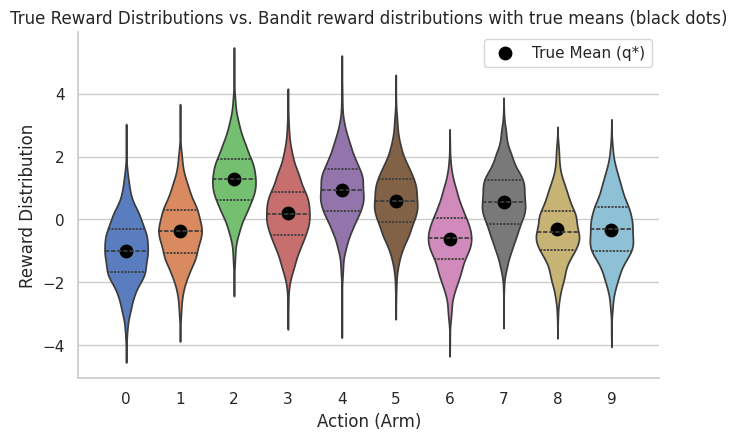

In [19]:
# --- YOUR CODE HERE ---
bandit = Bandit(k=10, mean=0, drift_std=1.0, reward_std=1.0, seed=123)
# --- END CODE ---
plot_true_distributions(bandit, 
                    title_suffix="Bandit reward distributions with true means (black dots)")

<div style="width:100%;box-sizing:border-box;margin:14px 0;border:1px solid #7A52CC;border-radius:10px;overflow:hidden;">

  <div style="background:#7A52CC;color:white;padding:10px 14px;font-weight:700;display:flex;align-items:center;gap:8px;">
    ❓ Question
  </div>

  <div style="background:white;padding:14px 16px;line-height:1.55;word-wrap:break-word;overflow-wrap:break-word;">

Reflect on the violin plot:

- Which arm appears to be the **best**?   
- How close are the **top-2 arms** in terms of their true means?  
- What does the **spread** of each violin suggest about uncertainty in the rewards?

<details>
  <summary style="cursor: pointer; font-weight: bold;">Click here for a hint!</summary>
  <div style="border-top: 1px solid #eee; padding-top: 10px; margin-top: 10px;">
  <p>Remember, the optimal action is the one with the highest <i>expected</i> reward. In this plot, the expected value (or mean) of each arm's distribution is represented by the solid black dot at its center.</p>

$$
q^*(a) = \mathbb{E}[R \mid a]
$$  

  </div>
</details>

  </div>
</div>


In [20]:
best_arm = int(np.argmax(bandit.q_true))
sorted_means = np.sort(bandit.q_true)[::-1]
gap = float(sorted_means[0] - sorted_means[1])
print(f"Best arm = {best_arm}, q* = {bandit.q_true[best_arm]:.3f}; top-2 gap = {gap:.3f}")

Best arm = 2, q* = 1.288; top-2 gap = 0.368


# Section 2 — Agent Scaffold (Composition)

<div style="width:100%;box-sizing:border-box;margin:14px 0;border:1px solid #5B8DEF;border-radius:10px;overflow:hidden;">

  <div style="background:#5B8DEF;color:white;padding:10px 14px;font-weight:700;display:flex;align-items:center;gap:8px;">
    📘 Explanation
  </div>

  <div style="background:white;padding:14px 16px;line-height:1.55;word-wrap:break-word;overflow-wrap:break-word;">

An agent maintains:  

- Estimates of action values $Q(a)$  
- Counts of visits $N(a)$  

A **policy** chooses actions based on $(Q, N, t)$.  
An **update rule** adjusts $(Q, N)$ after observing $(\text{action}, \text{reward})$.  

To stay modular, our agent only needs:  

- <code>choose_action</code>  
- <code>update</code>  
- <code>reset</code>  

👉 Convention:  
- A <strong>policy class</strong> implements <code>choose_action(Q, N, t)</code> → returns action.  
- An <strong>update rule class</strong> implements <code>update(Q, N, action, reward)</code> → returns updated $(Q, N)$.  

This design makes the agent flexible — you can swap in different policies or update rules without rewriting the agent.
  </div>
</div>


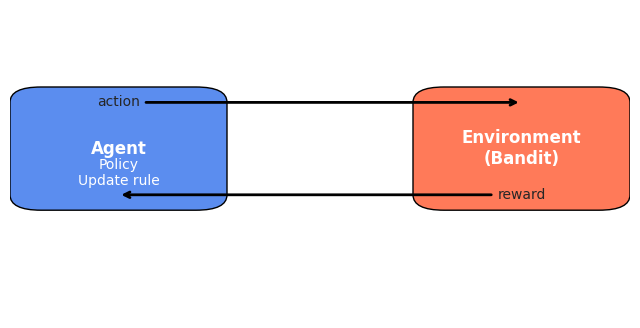

In [21]:
plot_agent_environment_interaction()

<div style="width:100%;box-sizing:border-box;margin:14px 0;border:1px solid #2DB380;border-radius:10px;overflow:hidden;">

  <div style="background:#2DB380;color:white;padding:10px 14px;font-weight:700;display:flex;align-items:center;gap:8px;">
    🛠️ Task 3
  </div>

  <div style="background:white;padding:14px 16px;line-height:1.55;word-wrap:break-word;overflow-wrap:break-word;">

Implement the **BanditAgent** class.  

- <code>choose_action()</code>: Ask the policy which action to take.  
- <code>update(action, reward)</code>: Increase <code>t</code> and update estimates via the update rule.  
- <code>reset()</code>: Reinitialize <code>Q</code>, <code>N</code>, and <code>t</code>.  

⚠️ Don’t worry if <code>policy.choose_action</code> or <code>update_rule.update</code> look mysterious — you’ll implement those in the **next tasks**.

  </div>
</div>


<div style="width:100%;box-sizing:border-box;margin:14px 0;border:1px solid #F2B824;border-radius:10px;overflow:hidden;">

  <div style="background:#F2B824;color:white;padding:10px 14px;font-weight:700;display:flex;align-items:center;gap:8px;">
    💡 Hint
  </div>

  <div style="background:white;padding:14px 16px;line-height:1.55;word-wrap:break-word;overflow-wrap:break-word;">

<details>
  <summary style="cursor: pointer; font-weight: bold; color: #555;">Click here for a hint!</summary>
  <div style="border-top: 1px solid #eee; padding-top: 10px; margin-top: 10px;">

- <code>policy.choose_action(Q, N, t)</code> will return an action index.  
- <code>update_rule.update(Q, N, action, reward)</code> will return updated arrays.  
  - For now, treat these as **black boxes** — they’ll be implemented next.  
- In <code>reset()</code>, reinitialize <code>Q</code> (to <code>initial_q_value</code>), <code>N</code> (to zeros), and <code>t</code> (to 0). 

  </div>
</details>

  </div>
</div>


In [22]:
class BanditAgent:
    """
    A flexible agent for the k-armed bandit problem,
    composed of a policy and an update rule.
    """

    def __init__(self, k: int, policy, update_rule, initial_q_value=0.0):
        # Number of arms
        self.k = int(k)
        # Strategy components
        self.policy = policy
        self.update_rule = update_rule
        # Initial Q values (optimistic initialization possible)
        self.initial_q_value = float(initial_q_value)
        # Initialize Q, N, and timestep
        self.reset()

    def choose_action(self):
        # --- YOUR CODE HERE ---
        # Delegate action selection to the policy
        return self.policy(self)
        # --- END CODE ---

    def update(self, action, reward):
        # --- YOUR CODE HERE ---
        # Increment timestep
        self.t += 1
        # Delegate update to the update rule
        self.update_rule(self.Q, self.N, action, reward)
        # --- END CODE ---

    def reset(self):
        # --- YOUR CODE HERE ---
        # Reset estimates, counts, and timestep
        self.Q = np.full(self.k, self.initial_q_value)
        self.N = np.zeros(self.k, dtype=int)
        self.t: int = 0
        # --- END CODE ---


# Section 3 — Update Rules - Sample Average vs Weighted Average

<div style="width:100%;box-sizing:border-box;margin:14px 0;border:1px solid #5B8DEF;border-radius:10px;overflow:hidden;">

  <div style="background:#5B8DEF;color:white;padding:10px 14px;font-weight:700;display:flex;align-items:center;gap:8px;">
    📘 Explanation
  </div>

  <div style="background:white;padding:14px 16px;line-height:1.55;word-wrap:break-word;overflow-wrap:break-word;">

In this section we focus on the <em>update rule</em>: how to revise an action-value estimate after seeing a reward.

We maintain estimates $Q(a)$ and, after choosing $a_t$ and observing reward $R_t$, we update via the generic incremental form:

$$
Q_{t+1}(a) \;=\; Q_t(a) + \alpha_t(a)\,\big(R_t - Q_t(a)\big).
$$

Different update rules correspond to different choices of the step size $\alpha_t(a)$.  
We’ll implement two canonical choices and compare their behavior empirically on a simple testbed—before discussing <em>why</em> they differ.

  </div>
</div>


<div style="width:100%;box-sizing:border-box;margin:14px 0;border:1px solid #2DB380;border-radius:10px;overflow:hidden;">

  <div style="background:#2DB380;color:white;padding:10px 14px;font-weight:700;display:flex;align-items:center;gap:8px;">
    🛠️ Task 4
  </div>

  <div style="background:white;padding:14px 16px;line-height:1.55;word-wrap:break-word;overflow-wrap:break-word;">

Implement the **SampleAverage** update rule:  

- Step size is the reciprocal of the visit count $N(a)$.  
- Update applies **only** to the chosen action $a_t$.  

Your class should define an <code>update(Q, N, action, reward)</code> method that:  

1. Increments $N(a_t)$.  
2. Applies the update rule  
   $$
   Q(a_t) \; \leftarrow \; Q(a_t) + \tfrac{1}{N(a_t)}\,(R_t - Q(a_t)).
   $$  

Return the updated $(Q, N)$.

  </div>
</div>


<div style="width:100%;box-sizing:border-box;margin:14px 0;border:1px solid #F2B824;border-radius:10px;overflow:hidden;">

  <div style="background:#F2B824;color:white;padding:10px 14px;font-weight:700;display:flex;align-items:center;gap:8px;">
    💡 Hint
  </div>

  <div style="background:white;padding:14px 16px;line-height:1.55;word-wrap:break-word;overflow-wrap:break-word;">

<details>
  <summary style="cursor: pointer; font-weight: bold; color: #555;">Click here for a hint!</summary>
  <div style="border-top: 1px solid #eee; padding-top: 10px; margin-top: 10px;">

- Remember to **increment $N(a)$ first**.  
- Compute step size as <code>1.0 / N[action]</code>.  
- Only update <code>Q[action]</code>, leave others unchanged.  
- A direct translation of the formula works fine:  

$$
Q[a] \leftarrow Q[a] + \alpha (R - Q[a]), \quad \alpha = \tfrac{1}{N[a]}.
$$  

  </div>
</details>

  </div>
</div>


In [23]:
class SampleAverage:
    """
    Incremental sample-average update rule for action values.
    Unbiased in stationary settings; step size shrinks as evidence accumulates.
    """
    def update(self, Q, N, action, reward):
        # --- YOUR CODE HERE ---
        # Increment count for this action
        N[action] += 1

        # Step size = 1 / N[action]
        alpha = 1.0 / N[action]

        # Update rule
        Q[action] += alpha * (reward - Q[action])

        return Q, N
        # --- END CODE ---


<div style="width:100%;box-sizing:border-box;margin:14px 0;border:1px solid #2DB380;border-radius:10px;overflow:hidden;">

  <div style="background:#2DB380;color:white;padding:10px 14px;font-weight:700;display:flex;align-items:center;gap:8px;">
    🛠️ Task 5
  </div>

  <div style="background:white;padding:14px 16px;line-height:1.55;word-wrap:break-word;overflow-wrap:break-word;">

Implement the **WeightedAverage** update rule:  

- Constructor should take a parameter <code>alpha</code>.  
- <code>update(Q, N, action, reward)</code> should update the estimate for the chosen action using step size <code>alpha</code>.  

$$
Q[a] \;\leftarrow\; Q[a] + \alpha \,(R - Q[a])
$$  

Return the updated <code>(Q, N)</code>.  

  </div>
</div>


<div style="width:100%;box-sizing:border-box;margin:14px 0;border:1px solid #F2B824;border-radius:10px;overflow:hidden;">

  <div style="background:#F2B824;color:white;padding:10px 14px;font-weight:700;display:flex;align-items:center;gap:8px;">
    💡 Hint
  </div>

  <div style="background:white;padding:14px 16px;line-height:1.55;word-wrap:break-word;overflow-wrap:break-word;">

<details>
  <summary style="cursor: pointer; font-weight: bold; color: #555;">Click here for a hint!</summary>
  <div style="border-top: 1px solid #eee; padding-top: 10px; margin-top: 10px;">

- Store <code>alpha</code> as a parameter in <code>__init__</code>.  
- In <code>update</code>, only update <code>Q[action]</code>.  
- Unlike SampleAverage, <code>N</code> is not used in the formula — but you should still increment it to track visits.  
- Use the incremental update rule:  
  $$
  Q[a] \gets Q[a] + \alpha \,(R - Q[a]).
  $$  

  </div>
</details>

  </div>
</div>


In [24]:
class WeightedAverage:
    """
    Update rule: Weighted Average with constant step size alpha.
    Useful in non-stationary environments.
    """
    def __init__(self, alpha: float):
        # --- YOUR CODE HERE ---
        self.alpha = float(alpha)
        # --- END CODE ---

    def update(self, Q, N, action, reward):
        # --- YOUR CODE HERE ---
        N[action] += 1

        Q[action] += self.alpha * (reward - Q[action])
        
        return Q, N
        # --- END CODE ---


<div style="width:100%;box-sizing:border-box;margin:14px 0;border:1px solid #FF7A59;border-radius:10px;overflow:hidden;">
  <div style="background:#FF7A59;color:white;padding:10px 14px;font-weight:700;display:flex;align-items:center;gap:8px;">
    🔬 Experiment
  </div>

  <div style="background:white;padding:14px 16px;line-height:1.55;word-wrap:break-word;overflow-wrap:break-word;">

Compare the two update rules on a **single-armed** bandit (no policy needed):

1. Generate one reward sequence from the arm’s distribution (fixed seed).  
2. Feed the **same** rewards to both update rules:  
   - <code>SampleAverage</code>  
   - <code>WeightedAverage</code> (e.g., <code>alpha=0.05</code>)  
3. Plot the estimate trajectories $Q_t$ together with the arm’s (hidden) true mean.

  </div>
</div>


<div style="width:100%;box-sizing:border-box;margin:14px 0;border:1px solid #2DB380;border-radius:10px;overflow:hidden;">

  <div style="background:#2DB380;color:white;padding:10px 14px;font-weight:700;display:flex;align-items:center;gap:8px;">
    🛠️ Task 6
  </div>

  <div style="background:white;padding:14px 16px;line-height:1.55;word-wrap:break-word;overflow-wrap:break-word;">

Instantiate a bandit

- A <code>Bandit</code> instance named <code>b</code> without drift.  

Instantiate the update rules:  

- A <code>SampleAverage</code> instance named <code>sa</code>.  
- A <code>WeightedAverage</code> instance named <code>wa</code> with <code>alpha = 0.05</code>.  

  </div>
</div>


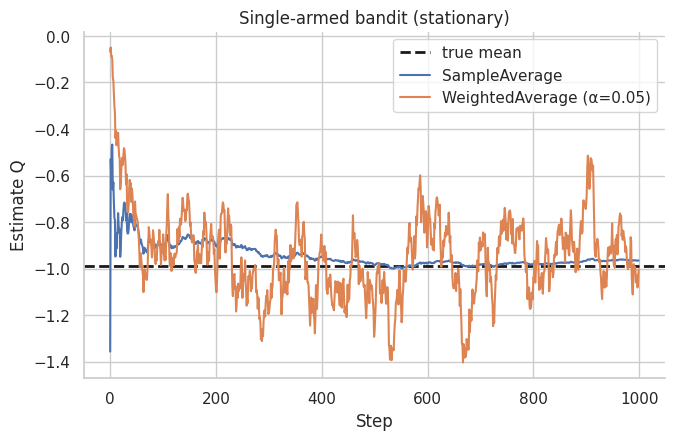

In [25]:
# --- YOUR CODE HERE ---
b = Bandit(1)

sa = SampleAverage()
wa = WeightedAverage(0.05)

# --- END CODE ---
single_armed_experiment(b, sa, wa, T=1000)


<div style="width:100%;box-sizing:border-box;margin:14px 0;border:1px solid #7A52CC;border-radius:10px;overflow:hidden;">

  <div style="background:#7A52CC;color:white;padding:10px 14px;font-weight:700;display:flex;align-items:center;gap:8px;">
    ❓ Question
  </div>

  <div style="background:white;padding:14px 16px;line-height:1.55;word-wrap:break-word;overflow-wrap:break-word;">

Compare the performance of <code>SampleAverage</code> and <code>WeightedAverage</code>.  

In the plots, one method consistently tracks the true value more closely as time goes on, while the other sometimes fluctuates around it.

- What do you notice about short-term speed of learning vs long-term accuracy?

- Why might one method eventually settle exactly on the true mean, while the other does not?

- How could bias and variance be playing a role here?

  </div>
</div>


<div style="width:100%;box-sizing:border-box;margin:14px 0;border:1px solid #F2B824;border-radius:10px;overflow:hidden;">

  <div style="background:#F2B824;color:white;padding:10px 14px;font-weight:700;display:flex;align-items:center;gap:8px;">
    💡 Hint
  </div>

  <div style="background:white;padding:14px 16px;line-height:1.55;word-wrap:break-word;overflow-wrap:break-word;">

<details>
  <summary style="cursor: pointer; font-weight: bold; color: #555;">Click here for a hint!</summary>
  <div style="border-top: 1px solid #eee; padding-top: 10px; margin-top: 10px;">

- An **unbiased** estimator converges to the true mean in expectation.  
- A **biased** estimator may systematically over- or under-estimate, even with infinite data.   
- Think about how the step size $\alpha_t = 1/N$ shrinks in sample average vs. stays fixed in weighted average.  

  </div>
</details>

  </div>
</div>


<div style="width:100%;box-sizing:border-box;margin:14px 0;border:1px solid #5B8DEF;border-radius:10px;overflow:hidden;">

  <div style="background:#5B8DEF;color:white;padding:10px 14px;font-weight:700;display:flex;align-items:center;gap:8px;">
    ✅ Explanation
  </div>

  <div style="background:white;padding:14px 16px;line-height:1.55;word-wrap:break-word;overflow-wrap:break-word;">

<details>
  <summary style="cursor: pointer; font-weight: bold; color: #555;">Click here to reveal the explanation</summary>
  <div style="border-top: 1px solid #eee; padding-top: 10px; margin-top: 10px;">

Notice that:

- **SampleAverage** steadily approaches the true mean.  
- **WeightedAverage** keeps fluctuating around the true mean.  

The difference comes from the step size:  
- Sample average makes smaller updates as $N(a)$ grows.  
- Weighted average always updates with the same step size.  

As a result, sample average provides an **unbiased and stable estimate** of the action value.

  </div>
</details>

  </div>
</div>


<div style="width:100%;box-sizing:border-box;margin:14px 0;border:1px solid #2DB380;border-radius:10px;overflow:hidden;">

  <div style="background:#2DB380;color:white;padding:10px 14px;font-weight:700;display:flex;align-items:center;gap:8px;">
    🛠️ Task 7
  </div>

  <div style="background:white;padding:14px 16px;line-height:1.55;word-wrap:break-word;overflow-wrap:break-word;">

Instantiate a **non-stationary** 1-armed bandit and the two update rules:

- Use <code>Bandit</code> with <code>nonstationary=True</code> and a small <code>drift_std</code> (e.g. <code>0.01</code>).  
- Create a <code>SampleAverage</code> instance.  
- Create a <code>WeightedAverage</code> instance with <code>α = 0.01</code>.  

Name your variables <code>bd</code>, <code>sa</code>, and <code>wa</code> so they can be passed to the experiment function.

  </div>
</div>


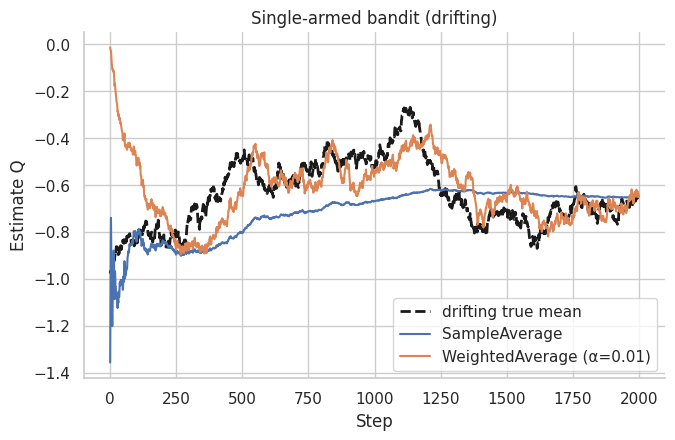

In [45]:
# --- YOUR CODE HERE ---
bd = Bandit(1, nonstationary=True, drift_std=0.01)

sa = SampleAverage()
wa = WeightedAverage(0.01)


# --- END CODE ---
single_armed_experiment(bd, sa, wa, T=2000 )

<div style="width:100%;box-sizing:border-box;margin:14px 0;border:1px solid #7A52CC;border-radius:10px;overflow:hidden;">

  <div style="background:#7A52CC;color:white;padding:10px 14px;font-weight:700;display:flex;align-items:center;gap:8px;">
    ❓ Question
  </div>

  <div style="background:white;padding:14px 16px;line-height:1.55;word-wrap:break-word;overflow-wrap:break-word;">

After running the second experiment (with drift), compare it to the first:

- What is the **key difference** between the two environments?
- Which update rule performs better now, and **why**?
- How would you name these two kinds of environments using standard RL terminology?

  </div>
</div>


<div style="width:100%;box-sizing:border-box;margin:14px 0;border:1px solid #F2B824;border-radius:10px;overflow:hidden;">

  <div style="background:#F2B824;color:white;padding:10px 14px;font-weight:700;display:flex;align-items:center;gap:8px;">
    💡 Hint
  </div>

  <div style="background:white;padding:14px 16px;line-height:1.55;word-wrap:break-word;overflow-wrap:break-word;">

<details>
  <summary style="cursor: pointer; font-weight: bold; color: #555;">Click here for a hint!</summary>
  <div style="border-top: 1px solid #eee; padding-top: 10px; margin-top: 10px;">

In the second experiment, the arm’s underlying value changes over time.  
Which update rule reacts **faster** to recent rewards?  
What does that suggest about how much each method “remembers” the past?

  </div>
</details>

  </div>
</div>


<div style="width:100%;box-sizing:border-box;margin:14px 0;border:1px solid #5B8DEF;border-radius:10px;overflow:hidden;">

  <div style="background:#5B8DEF;color:white;padding:10px 14px;font-weight:700;display:flex;align-items:center;gap:8px;">
    ✅ Intuitive Explanation
  </div>

  <div style="background:white;padding:14px 16px;line-height:1.55;word-wrap:break-word;overflow-wrap:break-word;">

<details>
  <summary style="cursor: pointer; font-weight: bold; color: #555;">Click here to reveal the explanation</summary>
  <div style="border-top: 1px solid #eee; padding-top: 10px; margin-top: 10px;">

- **First environment:** the true value is constant → a <strong>stationary</strong> bandit.  
  - <em>SampleAverage</em> works well: it keeps refining estimates and stabilizes over time.  

- **Second environment:** the true value drifts → a <strong>non-stationary</strong> bandit.  
  - <em>WeightedAverage</em> adapts faster because it focuses on recent rewards and forgets old ones.  

**Takeaway:**  
- Stationary → SampleAverage is more reliable.  
- Non-stationary → WeightedAverage handles change better.  

  </div>
</details>

  </div>
</div>

<div style="width:100%;box-sizing:border-box;margin:14px 0;border:1px solid #5B8DEF;border-radius:10px;overflow:hidden;">

  <div style="background:#5B8DEF;color:white;padding:10px 14px;font-weight:700;display:flex;align-items:center;gap:8px;">
    ✅ Technical Explanation
  </div>

  <div style="background:white;padding:14px 16px;line-height:1.55;word-wrap:break-word;overflow-wrap:break-word;">

<details>
  <summary style="cursor: pointer; font-weight: bold; color: #555;">Click here to reveal the explanation</summary>
  <div style="border-top: 1px solid #eee; padding-top: 10px; margin-top: 10px;">

**SampleAverage** (step size $1/N$):  
- ✅ **Unbiased** — in expectation, converges to the true mean.  
- ✅ **Full convergence** — estimates stabilize as $N \to \infty$.  
- ✅ **Variance shrinks** — more samples → less noise.  

**WeightedAverage** (constant $\alpha$):  
- ⚠️ **Biased** — never exactly matches the true mean.  
- ⚠️ **No full convergence** — estimates fluctuate forever.  
- ✅ **Responsive** — adapts quickly to changes in the environment.  

👉 This is why SampleAverage shines in stationary bandits, while WeightedAverage is better in drifting ones.  

  </div>
</details>

  </div>
</div>

# Section 4 — Policies

<div style="width:100%;box-sizing:border-box;margin:14px 0;border:1px solid #5B8DEF;border-radius:10px;overflow:hidden;">

  <div style="background:#5B8DEF;color:white;padding:10px 14px;font-weight:700;display:flex;align-items:center;gap:8px;">
    📘 Explanation
  </div>

  <div style="background:white;padding:14px 16px;line-height:1.55;word-wrap:break-word;overflow-wrap:break-word;">

A **greedy policy** always selects the action with the highest estimated value:

$$
a_t = \arg\max_a Q(a)
$$

This means the agent is purely exploitative — it never explores actions that look worse.  
Greedy is the simplest possible policy: just pick the current best estimate.

  </div>
</div>


<div style="width:100%;box-sizing:border-box;margin:14px 0;border:1px solid #2DB380;border-radius:10px;overflow:hidden;">

  <div style="background:#2DB380;color:white;padding:10px 14px;font-weight:700;display:flex;align-items:center;gap:8px;">
    🛠️ Task 8
  </div>

  <div style="background:white;padding:14px 16px;line-height:1.55;word-wrap:break-word;overflow-wrap:break-word;">

Implement a <strong>NaiveGreedy</strong> policy:

- <code>choose_action(Q, N, t)</code> → return <code>np.argmax(Q)</code>.  


  </div>
</div>


In [27]:
class NaiveGreedy:
    """
    Naive greedy policy: always pick the action with the largest Q estimate.
    Does not break ties randomly.
    """
    def choose_action(self, Q, N, t):
        # --- YOUR CODE HERE ---

        # --- END CODE ---
        pass


<div style="width:100%;box-sizing:border-box;margin:14px 0;border:1px solid #FF7A59;border-radius:10px;overflow:hidden;">
  <div style="background:#FF7A59;color:white;padding:10px 14px;font-weight:700;display:flex;align-items:center;gap:8px;">
    🔬 Experiment
  </div>

  <div style="background:white;padding:14px 16px;line-height:1.55;word-wrap:break-word;overflow-wrap:break-word;">

Run <strong>NaiveGreedy</strong> on a 10-armed bandit and visualize before/after:

1) Plot the bandit’s reward distributions (violin) and true means.  
2) Train the agent for <code>T</code> steps using <code>SampleAverage</code> updates.  
3) Plot the same violin again with the learned estimates $\;Q\;$ overlaid.

  </div>
</div>


<div style="width:100%;box-sizing:border-box;margin:14px 0;border:1px solid #2DB380;border-radius:10px;overflow:hidden;">

  <div style="background:#2DB380;color:white;padding:10px 14px;font-weight:700;display:flex;align-items:center;gap:8px;">
    🛠️ Task 9
  </div>

  <div style="background:white;padding:14px 16px;line-height:1.55;word-wrap:break-word;overflow-wrap:break-word;">

1. Create a <code>NaiveGreedy</code> policy object with variable name <code>policy</code>.  
2. Create a <code>SampleAverage</code> update rule object with variable name <code>update_rule</code>.  
3. Instantiate a 10-armed bandit <code>Bandit</code> with variable name <code>b</code> and starting seed <code>seed=1234</code>.  
4. Combine them into a <code>BanditAgent</code> named <code>agent</code>.  


  </div>
</div>


In [28]:
# --- YOUR CODE HERE ---




# --- END CODE ---

# 1) Visualize BEFORE training
plot_true_distributions(b,  estimated_values=agent.Q, title_suffix="Before Training (NaiveGreedy)")

# 2) Train for T steps
T = 50
rewards, actions = [], []
for t in range(T):
    a = agent.choose_action()
    r = b.step(a)
    agent.update(a, r)
    rewards.append(r)
    actions.append(a)

# 3) Visualize AFTER training with learned Q overlaid
plot_true_distributions(b, estimated_values=agent.Q, title_suffix=f"After {T} Steps (NaiveGreedy)")

# Optional: counts + quick sanity plots
print("Action counts:", agent.N)

plt.figure(figsize=(7.5, 3.8))
plt.bar(np.arange(b.k), agent.N, tick_label=[f"{i}" for i in range(b.k)])
plt.xlabel("Arm")
plt.ylabel("Times selected")
plt.title("NaiveGreedy Action Counts")
plt.show()


NameError: name 'agent' is not defined

<div style="width:100%;box-sizing:border-box;margin:14px 0;border:1px solid #7A52CC;border-radius:10px;overflow:hidden;">

  <div style="background:#7A52CC;color:white;padding:10px 14px;font-weight:700;display:flex;align-items:center;gap:8px;">
    ❓ Question
  </div>

  <div style="background:white;padding:14px 16px;line-height:1.55;word-wrap:break-word;overflow-wrap:break-word;">

NaiveGreedy only selected a few arms (e.g. the first 6).  
- Why might this happen?  
- How do <em>initial estimates</em> and <em>ties</em> influence the outcome?  
- If ties are broken deterministically, what does that imply for long-term exploration?  
- How might we <strong>improve</strong> this policy?

  </div>
</div>


<div style="width:100%;box-sizing:border-box;margin:14px 0;border:1px solid #5B8DEF;border-radius:10px;overflow:hidden;">

  <div style="background:#5B8DEF;color:white;padding:10px 14px;font-weight:700;display:flex;align-items:center;gap:8px;">
    📘 Explanation
  </div>

  <div style="background:white;padding:14px 16px;line-height:1.55;word-wrap:break-word;overflow-wrap:break-word;">

<details>
  <summary style="cursor: pointer; font-weight: bold; color: #555;">Click here to reveal the explanation</summary>
  <div style="border-top: 1px solid #eee; padding-top: 10px; margin-top: 10px;">

NaiveGreedy breaks ties <em>deterministically</em> (always picking the first max index).  
This introduces a **bias**: if multiple arms share the highest estimate, the first one is always chosen.  

To fix this, our improved <strong>Greedy</strong> policy will:  
- Find <em>all</em> actions tied for the maximum $Q(a)$.  
- Pick one <em>uniformly at random</em>.  

This ensures fair exploration whenever estimates are equal.
  </div>
</details>
  </div>
</div>


<div style="width:100%;box-sizing:border-box;margin:14px 0;border:1px solid #2DB380;border-radius:10px;overflow:hidden;">

  <div style="background:#2DB380;color:white;padding:10px 14px;font-weight:700;display:flex;align-items:center;gap:8px;">
    🛠️ Task 10
  </div>

  <div style="background:white;padding:14px 16px;line-height:1.55;word-wrap:break-word;overflow-wrap:break-word;">

Implement the <strong>Greedy</strong> policy:  

- Identify all indices with the maximum value in <code>Q</code>.  
- Randomly select one of them (uniform tie-breaking).  
- Provide a <code>choose_action(Q, N, t)</code> method.  

  </div>
</div>


<div style="width:100%;box-sizing:border-box;margin:14px 0;border:1px solid #F2B824;border-radius:10px;overflow:hidden;">

  <div style="background:#F2B824;color:white;padding:10px 14px;font-weight:700;display:flex;align-items:center;gap:8px;">
    💡 Hint
  </div>

  <div style="background:white;padding:14px 16px;line-height:1.55;word-wrap:break-word;overflow-wrap:break-word;">

<details>
  <summary style="cursor: pointer; font-weight: bold; color: #555;">Click here for a hint!</summary>
  <div style="border-top: 1px solid #eee; padding-top: 10px; margin-top: 10px;">

Use <code>np.where</code> to find all max indices:  

<pre><code>best_actions = np.where(Q == Q.max())[0]</code></pre>  

Then sample uniformly:  

<pre><code>return np.random.choice(best_actions)</code></pre>  

  </div>
</details>

  </div>
</div>


In [ ]:
class Greedy:
    """
    Greedy policy with random tie-breaking.
    Always selects an action with the maximum Q estimate,
    breaking ties uniformly at random.
    """
    def choose_action(self, Q, N, t):
        # --- YOUR CODE HERE ---


        # --- END CODE ---
        pass


<div style="width:100%;box-sizing:border-box;margin:14px 0;border:1px solid #F2B824;border-radius:10px;overflow:hidden;">

  <div style="background:#F2B824;color:white;padding:10px 14px;font-weight:700;display:flex;align-items:center;gap:8px;">
    💡 Reproducibility Tip
  </div>

  <div style="background:white;padding:14px 16px;line-height:1.55;word-wrap:break-word;overflow-wrap:break-word;">

<details>
  <summary style="cursor: pointer; font-weight: bold; color: #555;">Click here to learn about random number generators</summary>
  <div style="border-top: 1px solid #eee; padding-top: 10px; margin-top: 10px;">

In our policies, we used <code>np.random</code> for simplicity.  
For more control and reproducibility, NumPy recommends creating a **random number generator (RNG)**:


<code>  rng = np.random.default_rng(seed=42) </code> 

You can then use it instead of the global random state:

<code>  action = rng.choice(actions) </code> 



<div style="width:100%;box-sizing:border-box;margin:14px 0;border:1px solid #FF7A59;border-radius:10px;overflow:hidden;">
  <div style="background:#FF7A59;color:white;padding:10px 14px;font-weight:700;display:flex;align-items:center;gap:8px;">
    🔬 Experiment
  </div>

  <div style="background:white;padding:14px 16px;line-height:1.55;word-wrap:break-word;overflow-wrap:break-word;">

Compare the <strong>NaiveGreedy</strong> agent and the improved <strong>Greedy</strong> agent.  
Do they explore actions differently when there are ties in the estimates?  

  </div>
</div>


<div style="width:100%;box-sizing:border-box;margin:14px 0;border:1px solid #2DB380;border-radius:10px;overflow:hidden;">

  <div style="background:#2DB380;color:white;padding:10px 14px;font-weight:700;display:flex;align-items:center;gap:8px;">
    🛠️ Task 11
  </div>

  <div style="background:white;padding:14px 16px;line-height:1.55;word-wrap:break-word;overflow-wrap:break-word;">

Create a <code>Greedy</code> policy agent and test it on a 10-armed bandit.  


1.  Use <code>Greedy()</code> as the policy (it breaks ties randomly).  
2. Use <code>SampleAverage()</code> as the update rule.  
3. Combine them into a <code>BanditAgent</code> named <code>greedy_agent</code>.  
4. Run the same experiment as before and visualize the results.  

  </div>
</div>


In [ ]:
# --- YOUR CODE HERE ---


# --- END CODE ---

# Run experiment
T = 500
for t in range(T):
    action = agent.choose_action()
    reward = b.pull(action)
    agent.update(action, reward)

# Plot reward distributions with estimates
plot_true_distributions(b, estimated_values=agent.Q, title_suffix="Greedy Agent")

# Plot action counts
print("Action counts:", agent.N)
plt.figure(figsize=(7.5, 3.8))
plt.bar(np.arange(b.k), agent.N)
plt.xticks(np.arange(b.k))  # ensure ticks match arms
plt.xlabel("Arm"); plt.ylabel("Times selected")
plt.title("Greedy Action Counts")
plt.show()

<div style="width:100%;box-sizing:border-box;margin:14px 0;border:1px solid #7A52CC;border-radius:10px;overflow:hidden;">

  <div style="background:#7A52CC;color:white;padding:10px 14px;font-weight:700;display:flex;align-items:center;gap:8px;">
    ❓ Question
  </div>

  <div style="background:white;padding:14px 16px;line-height:1.55;word-wrap:break-word;overflow-wrap:break-word;">

Both <em>NaiveGreedy</em> and <em>Greedy</em> may appear to get stuck in the same arms in our simple experiment.  

- Why might random tie-breaking still be an **important improvement** over always picking the first max?  
- In what kinds of environments could this small design choice matter more?  
- How does this relate to fairness and avoiding bias in learning agents?

  </div>
</div>


<div style="width:100%;box-sizing:border-box;margin:14px 0;border:1px solid #F2B824;border-radius:10px;overflow:hidden;">

  <div style="background:#F2B824;color:white;padding:10px 14px;font-weight:700;display:flex;align-items:center;gap:8px;">
    💡 Hint
  </div>

  <div style="background:white;padding:14px 16px;line-height:1.55;word-wrap:break-word;overflow-wrap:break-word;">

<details>
  <summary style="cursor: pointer; font-weight: bold; color: #555;">Click here for a hint!</summary>
  <div style="border-top: 1px solid #eee; padding-top: 10px; margin-top: 10px;">

- <em>NaiveGreedy</em> always resolves ties the same way (e.g., lowest index).  
- This creates a **systematic bias**: some arms are never explored if initial estimates tie.  
- <em>Greedy</em> avoids this by randomizing over tied actions — removing bias even if the learning outcome looks similar in small experiments.

  </div>
</details>

  </div>
</div>


<div style="width:100%;box-sizing:border-box;margin:14px 0;border:1px solid #5B8DEF;border-radius:10px;overflow:hidden;">

  <div style="background:#5B8DEF;color:white;padding:10px 14px;font-weight:700;display:flex;align-items:center;gap:8px;">
    ✅ Explanation
  </div>

  <div style="background:white;padding:14px 16px;line-height:1.55;word-wrap:break-word;overflow-wrap:break-word;">

<details>
  <summary style="cursor: pointer; font-weight: bold; color: #555;">Click here to reveal the explanation</summary>
  <div style="border-top: 1px solid #eee; padding-top: 10px; margin-top: 10px;">

- In this experiment, both <em>NaiveGreedy</em> and <em>Greedy</em> quickly locked into the same arm — so the results look similar.  
- But notice how <em>NaiveGreedy</em> only selected the lowest-index arms when ties happened.  
- <em>Greedy</em> breaks ties <strong>uniformly at random</strong>, which avoids systematic bias toward low-index arms.  

👉 Even if the difference doesn’t always appear in simple plots, random tie-breaking is crucial in larger or deterministic problems — it ensures fairness and prevents hidden bias from shaping the learning outcome.

  </div>
</details>

  </div>
</div>


<div style="width:100%;box-sizing:border-box;margin:14px 0;border:1px solid #5B8DEF;border-radius:10px;overflow:hidden;">

  <div style="background:#5B8DEF;color:white;padding:10px 14px;font-weight:700;display:flex;align-items:center;gap:8px;">
    📘 Explanation
  </div>

  <div style="background:white;padding:14px 16px;line-height:1.55;word-wrap:break-word;overflow-wrap:break-word;">

Purely greedy agents risk getting stuck on suboptimal arms because they never explore.  
The **ε-greedy** strategy balances this by:  

- With probability <strong>ε</strong>, choosing a random action (exploration).  
- With probability <strong>1 − ε</strong>, choosing the greedy action (exploitation).  

This simple mechanism ensures that every arm keeps a chance of being tried, reducing the risk of being trapped by early randomness.
  </div>
</div>


<div style="width:100%;box-sizing:border-box;margin:14px 0;border:1px solid #2DB380;border-radius:10px;overflow:hidden;">

  <div style="background:#2DB380;color:white;padding:10px 14px;font-weight:700;display:flex;align-items:center;gap:8px;">
    🛠️ Task 12
  </div>

  <div style="background:white;padding:14px 16px;line-height:1.55;word-wrap:break-word;overflow-wrap:break-word;">

Implement the <code>EpsilonGreedy</code> policy.  

- Its constructor should take <code>epsilon</code> (exploration probability) as input.  
- <code>choose_action(Q, N, t)</code>:  
  - With probability <code>epsilon</code> → pick a random arm.  
  - Otherwise → pick the greedy arm (break ties randomly, like <code>Greedy</code>).  

This way, your agent will sometimes explore, sometimes exploit.
  </div>
</div>


<div style="width:100%;box-sizing:border-box;margin:14px 0;border:1px solid #F2B824;border-radius:10px;overflow:hidden;">

  <div style="background:#F2B824;color:white;padding:10px 14px;font-weight:700;display:flex;align-items:center;gap:8px;">
    💡 Hint
  </div>

  <div style="background:white;padding:14px 16px;line-height:1.55;word-wrap:break-word;overflow-wrap:break-word;">

<details>
  <summary style="cursor: pointer; font-weight: bold; color: #555;">Click here for a hint!</summary>
  <div style="border-top: 1px solid #eee; padding-top: 10px; margin-top: 10px;">

- Use <code>np.random.rand()</code> to decide between explore vs exploit.  
- For exploration, use <code>np.random.randint(len(Q))</code> to pick a random action.  
- For exploitation, reuse the logic from <code>Greedy</code> with <code>np.where</code> and <code>np.random.choice</code>.  
- Don’t forget to store <code>epsilon</code> in <code>__init__</code>.

  </div>
</details>

  </div>
</div>


In [ ]:
class EpsilonGreedy:
    """
    Epsilon-greedy policy:
    - With probability epsilon: explore (random action).
    - With probability 1 - epsilon: exploit (best action so far, ties broken randomly).
    """
    def __init__(self, epsilon=0.1):
        self.epsilon = float(epsilon)

    def choose_action(self, Q, N, t):
        # --- YOUR CODE HERE ---

            # Explore: random arm
      
       
            # Exploit: best arm(s), random tie-break
           
         
        # --- END CODE ---
        pass


<div style="width:100%;box-sizing:border-box;margin:14px 0;border:1px solid #FF7A59;border-radius:10px;overflow:hidden;">
  <div style="background:#FF7A59;color:white;padding:10px 14px;font-weight:700;display:flex;align-items:center;gap:8px;">
    🔬 Experiment
  </div>
  <div style="background:white;padding:14px 16px;line-height:1.55;word-wrap:break-word;overflow-wrap:break-word;">

Compare a <strong>Greedy</strong> agent and an <strong>EpsilonGreedy</strong> agent on the same 10-armed bandit (stationary).  

1) Visualize the bandit (violin + true means).  
2) Train each agent for <code>T</code> steps on the same environment (separately).  
3) Visualize learned estimates $Q$ and action counts for each agent.

  </div>
</div>


<div style="width:100%;box-sizing:border-box;margin:14px 0;border:1px solid #2DB380;border-radius:10px;overflow:hidden;">
  <div style="background:#2DB380;color:white;padding:10px 14px;font-weight:700;display:flex;align-items:center;gap:8px;">
    🛠️ Task 13
  </div>
  <div style="background:white;padding:14px 16px;line-height:1.55;word-wrap:break-word;overflow-wrap:break-word;">

Create two agents with explicit composition:

1. Instantiate the bandit: <code>b = Bandit(k=10, mean=0.0, std=1.0, reward_std=1.0, seed=2024)</code>  
2. Create a <code>Greedy()</code> policy and a <code>SampleAverage()</code> update rule → <code>agent_greedy</code>  
3. Create an <code>EpsilonGreedy(epsilon=0.1)</code> policy and a <code>SampleAverage()</code> update rule → <code>agent_eps</code>  

Use the exact variable names: <code>b</code>, <code>agent_greedy</code>, <code>agent_eps</code>.
  </div>
</div>


In [ ]:
# --- YOUR CODE HERE ---





# --- END CODE ---

# 1) Visualize BEFORE training
# plot_true_distributions(b, title_suffix="Before Training (Greedy vs ε-Greedy)")


T = 600

# 2) Train GREEDY on a clone
b_g, rewards_g, actions_g = run_agent_on_clone(agent_greedy, b, T=T)

# 3) Train EPS-GREEDY on another clone
b_e, rewards_e, actions_e = run_agent_on_clone(agent_eps, b, T=T)

# 4) Visualize AFTER training: estimates overlay
plot_true_distributions(b_g, estimated_values=agent_greedy.Q, title_suffix=f"After {T} Steps (Greedy)")
plot_true_distributions(b_e, estimated_values=agent_eps.Q, title_suffix=f"After {T} Steps (ε-Greedy, ε={agent_eps.policy.epsilon})")

# 5) Action counts
print("Action counts (Greedy):", agent_greedy.N)
plt.figure(figsize=(7.5, 3.8))
plt.bar(np.arange(b.k), agent_greedy.N, tick_label=[f"{i}" for i in range(b.k)])
plt.xlabel("Arm"); plt.ylabel("Times selected"); plt.title("Greedy Action Counts")
plt.show()

print("Action counts (ε-Greedy):", agent_eps.N)
plt.figure(figsize=(7.5, 3.8))
plt.bar(np.arange(b.k), agent_eps.N, tick_label=[f"{i}" for i in range(b.k)])
plt.xlabel("Arm"); plt.ylabel("Times selected"); plt.title(f"ε-Greedy (ε={agent_eps.policy.epsilon}) Action Counts")
plt.show()


<div style="width:100%;box-sizing:border-box;margin:14px 0;border:1px solid #7A52CC;border-radius:10px;overflow:hidden;">

  <div style="background:#7A52CC;color:white;padding:10px 14px;font-weight:700;display:flex;align-items:center;gap:8px;">
    ❓ Question
  </div>

  <div style="background:white;padding:14px 16px;line-height:1.55;word-wrap:break-word;overflow-wrap:break-word;">

Compare the action counts and $Q$ estimates of the two agents:  

- Which arms did <em>ε-greedy</em> try that <em>greedy</em> ignored?  
- How does this affect the final estimates of $Q$?  
- What happens if you change <code>ε</code> to a smaller or larger value (e.g. 0.01 or 0.3)?  

  </div>
</div>


<div style="width:100%;box-sizing:border-box;margin:14px 0;border:1px solid #5B8DEF;border-radius:10px;overflow:hidden;">

  <div style="background:#5B8DEF;color:white;padding:10px 14px;font-weight:700;display:flex;align-items:center;gap:8px;">
    📘 Explanation
  </div>

  <div style="background:white;padding:14px 16px;line-height:1.55;word-wrap:break-word;overflow-wrap:break-word;">

So far, we plotted the agent’s **knowledge** (its $Q$ estimates).  
Now we evaluate **performance**: how much reward the agent actually collects. 

This distinction is important:  
- $Q$-plots show what the agent *believes*.  
- Reward curves show what the agent *achieves*.  

The helper function <code>run_bandit_experiment</code> simulates an agent interacting with a bandit:  

- At each step, the agent chooses an action according to its policy.  
- The bandit returns a reward.  
- The agent updates its estimates.  
- We record the reward obtained at each step.  

By plotting these step rewards, we can see how the agent’s performance changes over time.  

  </div>
</div>


<div style="width:100%;box-sizing:border-box;margin:14px 0;border:1px solid #FF7A59;border-radius:10px;overflow:hidden;">

  <div style="background:#FF7A59;color:white;padding:10px 14px;font-weight:700;display:flex;align-items:center;gap:8px;">
    🔬 Experiment
  </div>

  <div style="background:white;padding:14px 16px;line-height:1.55;word-wrap:break-word;overflow-wrap:break-word;">

We now compare **Greedy** and **ε-Greedy** agents in a 10-armed bandit.  

- Use <code>run_bandit_experiment</code> to simulate a learning run.  
- Use <code>plot_learning_curve</code> to visualize the **average reward over time**.  
- This experiment shows performance differences, not just estimates.  

  </div>
</div>

<div style="width:100%;box-sizing:border-box;margin:14px 0;border:1px solid #2DB380;border-radius:10px;overflow:hidden;">

  <div style="background:#2DB380;color:white;padding:10px 14px;font-weight:700;display:flex;align-items:center;gap:8px;">
    🛠️ Task 14
  </div>

  <div style="background:white;padding:14px 16px;line-height:1.55;word-wrap:break-word;overflow-wrap:break-word;">

Run the experiment for the following agents:  
- <em>Greedy</em>  
- <em>ε-Greedy</em> with <code>ε = 0.1</code>  
- <em>ε-Greedy</em> with <code>ε = 0.01</code>  

Use <code>plot_learning_curve</code> to visualize and compare their step rewards over time.  

  </div>
</div>


In [ ]:
results = run_bandit_experiment(
    Bandit,
    agent_factories={
        "Greedy": lambda: BanditAgent(10, Greedy(), SampleAverage()),
        "EpsilonGreedy(0.1)": lambda: BanditAgent(10, EpsilonGreedy(0.1), SampleAverage()),
        "EpsilonGreedy(0.01)": lambda: BanditAgent(10, EpsilonGreedy(0.01), SampleAverage())
    },
    steps=1000, k=10
)

plot_learning_curves(results, smoothing_window=10)

<div style="width:100%;box-sizing:border-box;margin:14px 0;border:1px solid #7A52CC;border-radius:10px;overflow:hidden;">

  <div style="background:#7A52CC;color:white;padding:10px 14px;font-weight:700;display:flex;align-items:center;gap:8px;">
    ❓ Question
  </div>

  <div style="background:white;padding:14px 16px;line-height:1.55;word-wrap:break-word;overflow-wrap:break-word;">

The learning curve looks very noisy.  
- Why do you think this happens?  
- What could we change in the experiment to get a more reliable picture of performance?

  </div>
</div>


<div style="width:100%;box-sizing:border-box;margin:14px 0;border:1px solid #FFB02E;border-radius:10px;overflow:hidden;">

  <div style="background:#FFB02E;color:white;padding:10px 14px;font-weight:700;display:flex;align-items:center;gap:8px;">
    💡 Hint
  </div>

  <div style="background:white;padding:14px 16px;line-height:1.55;word-wrap:break-word;overflow-wrap:break-word;">

<details>
  <summary style="cursor: pointer; font-weight: bold; color: #555;">Click here to reveal the hint</summary>
  <div style="border-top: 1px solid #eee; padding-top: 10px; margin-top: 10px;">

Each run is stochastic:  
- Rewards are noisy.  
- Action choices depend on randomness in tie-breaking and exploration.  

Averaging over **multiple runs** reduces this randomness and shows the true trend.

  </div>
</details>

  </div>
</div>


<div style="width:100%;box-sizing:border-box;margin:14px 0;border:1px solid #5B8DEF;border-radius:10px;overflow:hidden;">

  <div style="background:#5B8DEF;color:white;padding:10px 14px;font-weight:700;display:flex;align-items:center;gap:8px;">
    📘 Explanation
  </div>

  <div style="background:white;padding:14px 16px;line-height:1.55;word-wrap:break-word;overflow-wrap:break-word;">

To correctly measure **performance**: how much reward the agent actually earns, we need to:  

- Run each agent for many runs and track the **reward at each step**.  
- To reduce randomness, we average these step rewards across multiple runs.  
- This gives the **average reward curve**, showing how well the agent learns over time.  
- A small smoothing window can be applied to make the curve less noisy.


  </div>
</div>


<div style="width:100%;box-sizing:border-box;margin:14px 0;border:1px solid #2DB380;border-radius:10px;overflow:hidden;">

  <div style="background:#2DB380;color:white;padding:10px 14px;font-weight:700;display:flex;align-items:center;gap:8px;">
    🛠️ Task 15
  </div>

  <div style="background:white;padding:14px 16px;line-height:1.55;word-wrap:break-word;overflow-wrap:break-word;">

Now rerun the simulation with <code>runs=100</code>, <code>runs=200</code>, and <code>runs=1000</code>.  
Compare the resulting learning curves — how does increasing the number of runs change the plot?  

  </div>
</div>


In [ ]:
results = run_bandit_experiment(
    Bandit,
    agent_factories={
        "Greedy": lambda: BanditAgent(10, Greedy(), SampleAverage()),
        "EpsilonGreedy(0.1)": lambda: BanditAgent(10, EpsilonGreedy(0.1), SampleAverage()),
        "EpsilonGreedy(0.01)": lambda: BanditAgent(10, EpsilonGreedy(0.01), SampleAverage())
    },
    runs=100, steps=1000, k=10
)

plot_learning_curves(results, smoothing_window=10)


<div style="width:100%;box-sizing:border-box;margin:14px 0;border:1px solid #7A52CC;border-radius:10px;overflow:hidden;">

  <div style="background:#7A52CC;color:white;padding:10px 14px;font-weight:700;display:flex;align-items:center;gap:8px;">
    ❓ Question
  </div>

  <div style="background:white;padding:14px 16px;line-height:1.55;word-wrap:break-word;overflow-wrap:break-word;">

Look at the learning curves of **Greedy** vs. **ε-Greedy**:  
- Which agent achieves higher long-term rewards?  
- Why does adding random exploration help in this setting?  
- How does ε affect the trade-off between *exploring* new arms and *exploiting* the current best estimate?  

  </div>
</div>


<div style="width:100%;box-sizing:border-box;margin:14px 0;border:1px solid #FFB02E;border-radius:10px;overflow:hidden;">

  <div style="background:#FFB02E;color:white;padding:10px 14px;font-weight:700;display:flex;align-items:center;gap:8px;">
    💡 Hint
  </div>

  <div style="background:white;padding:14px 16px;line-height:1.55;word-wrap:break-word;overflow-wrap:break-word;">

Try running the experiment with different values of <code>ε</code> (e.g. 0.01, 0.1, 0.2).  
- Small <code>ε</code> → more exploitation, less exploration.  
- Large <code>ε</code> → more exploration, but possibly lower short-term reward.  

Observe how the balance shifts in the learning curves.

  </div>
</div>


<div style="width:100%;box-sizing:border-box;margin:14px 0;border:1px solid #FF9800;border-radius:10px;overflow:hidden;">

  <div style="background:#FF9800;color:white;padding:10px 14px;font-weight:700;display:flex;align-items:center;gap:8px;">
    📘 After-Lab Assignment
  </div>

  <div style="background:white;padding:14px 16px;line-height:1.55;word-wrap:break-word;overflow-wrap:break-word;">

In this assignment you will extend your bandit agents with more advanced exploration strategies and compare their performance.  

### 1. Methods to Implement
- **ε-Greedy** (with tunable ε)  
- **Greedy with Optimistic Initialization** (via `initial_q_value`)  
- **UCB** with exploration parameter `c`  
- **Softmax** with temperature parameter `τ`  

---

### 2. Simulation Setup
- 10-armed stationary bandit  
- Arm means: drawn from $\mathcal{N}(0,1)$  
- Rewards: $\mathcal{N}(q^*(a), 1)$  
- Runs = 200, Steps = 1000  

---

### 3. Required Plots
- **Plot 1:** ε-Greedy with ε ∈ {0.01, 0.1, 0.2} → Average reward curves.  
- **Plot 2:** ε-Greedy (ε=0.1) vs Greedy with Optimistic Initialization (Q₀ ∈ {0, 2, 5}) → Average reward curves.  
- **Plot 3:** UCB with c ∈ {0.5, 1, 2, 5} → Average reward curves.  
- **Plot 4:** Softmax with τ ∈ {0.1, 0.5, 1.0} → Average reward curves.  
- **Plot 5:** Best ε-Greedy vs Best UCB vs Best Softmax (student-tuned parameters).  

---

### 4. Questions
1. ε-Greedy: How does increasing ε change exploration and long-term reward?  
2. Optimistic Initialization: How do optimistic Q₀ values influence early exploration?  
3. UCB: What does small vs large c resemble compared to ε-Greedy? Which c performs best?  
4. Softmax: How does τ control the balance between greedy and exploratory actions?  
5. Comparison: Which strategy performs best overall? Which is most robust to parameter choice?  

---

### 5. Deliverables
Submit:  
1. The **five labeled plots** (as specified above).  
2. **Short written answers (2–4 sentences each)** to the guiding questions.  
3. Reflection: Which method would you pick for an unknown bandit? Why?  

  </div>
</div>
